In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break

/kaggle/input


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/hijest
/kaggle/input/datasets/hijest/genre-classification-dataset-imdb
/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported! ✅")

Libraries imported! ✅


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/description.txt
/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/test_data_solution.txt
/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/test_data.txt
/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/train_data.txt


In [5]:
# Train data load karo
train_data = []
with open('/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/train_data.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split(' ::: ')
        if len(parts) == 4:
            train_data.append({
                'id': parts[0],
                'title': parts[1],
                'genre': parts[2],
                'description': parts[3]
            })

df = pd.DataFrame(train_data)
print(df.shape)
print(df.head())
print(df['genre'].value_counts())

(54214, 4)
  id                             title     genre  \
0  1      Oscar et la dame rose (2009)     drama   
1  2                      Cupid (1997)  thriller   
2  3  Young, Wild and Wonderful (1980)     adult   
3  4             The Secret Sin (1915)     drama   
4  5            The Unrecovered (2007)     drama   

                                         description  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
anim

In [6]:
# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

df['clean_desc'] = df['description'].apply(clean_text)
print("Text cleaned! ✅")
print(df['clean_desc'].head())

Text cleaned! ✅
0    listening in to a conversation between his doc...
1    a brother and sister with a past incestuous re...
2    as the bus empties the students for their fiel...
3    to help their unemployed father make ends meet...
4    the films title refers not only to the unrecov...
Name: clean_desc, dtype: object


In [7]:
top_genres = df['genre'].value_counts().head(10).index
df_filtered = df[df['genre'].isin(top_genres)]
print("Filtered shape:", df_filtered.shape)
print(df_filtered['genre'].value_counts())

Filtered shape: (47039, 5)
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64


In [8]:
X = df_filtered['clean_desc']
y = df_filtered['genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

print("TF-IDF done! ✅")
print("Train size:", X_train_tf.shape)

TF-IDF done! ✅
Train size: (37631, 5000)


In [9]:
model = MultinomialNB()
model.fit(X_train_tf, y_train)
print("Model trained! ✅")

Model trained! ✅


In [10]:
y_pred = model.predict(X_test_tf)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print(classification_report(y_test, y_pred))

Accuracy: 59.65 %
              precision    recall  f1-score   support

      action       0.68      0.09      0.17       264
      comedy       0.59      0.45      0.51      1475
 documentary       0.68      0.87      0.76      2642
       drama       0.51      0.82      0.63      2722
      family       0.00      0.00      0.00       155
      horror       0.78      0.32      0.46       450
  reality-tv       1.00      0.01      0.02       168
       short       0.63      0.10      0.18       978
    thriller       1.00      0.02      0.05       341
     western       0.98      0.59      0.74       213

    accuracy                           0.60      9408
   macro avg       0.68      0.33      0.35      9408
weighted avg       0.63      0.60      0.54      9408



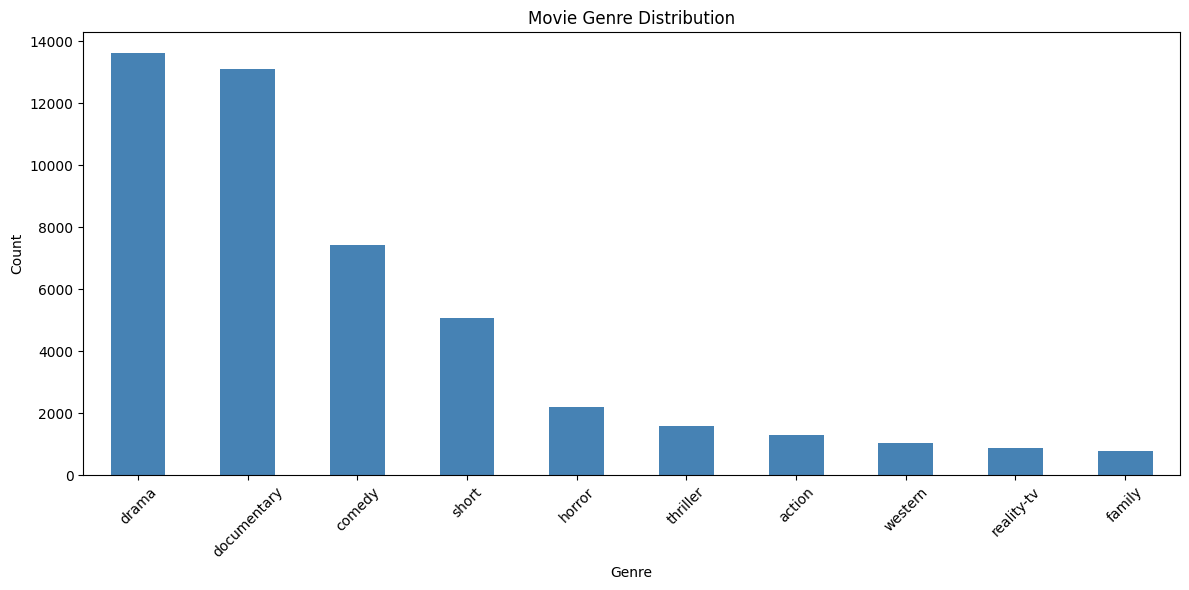

In [11]:
plt.figure(figsize=(12, 6))
df_filtered['genre'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Movie Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

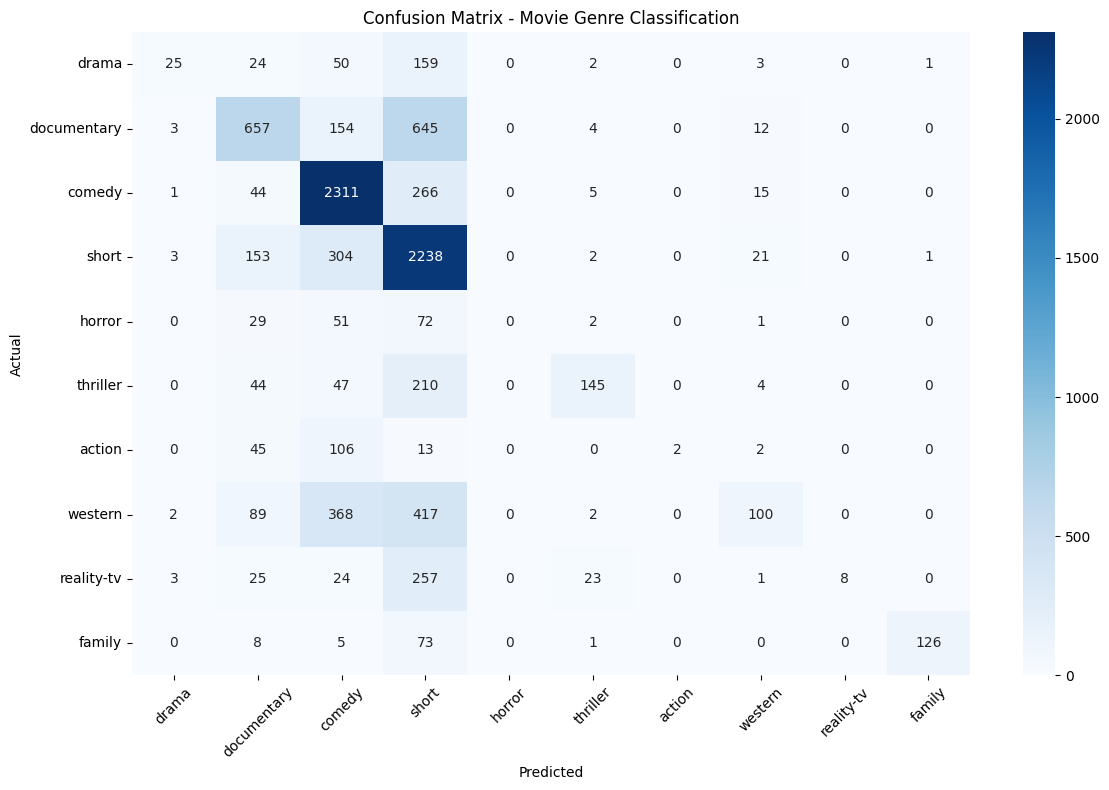

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_genres,
            yticklabels=top_genres)
plt.title('Confusion Matrix - Movie Genre Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tf, y_train)
nb_pred = nb.predict(X_test_tf)
print("Naive Bayes Accuracy:", round(accuracy_score(y_test, nb_pred) * 100, 2), "%")

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tf, y_train)
lr_pred = lr.predict(X_test_tf)
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")

# SVM
svm = LinearSVC()
svm.fit(X_train_tf, y_train)
svm_pred = svm.predict(X_test_tf)
print("SVM Accuracy:", round(accuracy_score(y_test, svm_pred) * 100, 2), "%")

Naive Bayes Accuracy: 59.65 %
Logistic Regression Accuracy: 65.58 %
SVM Accuracy: 63.69 %


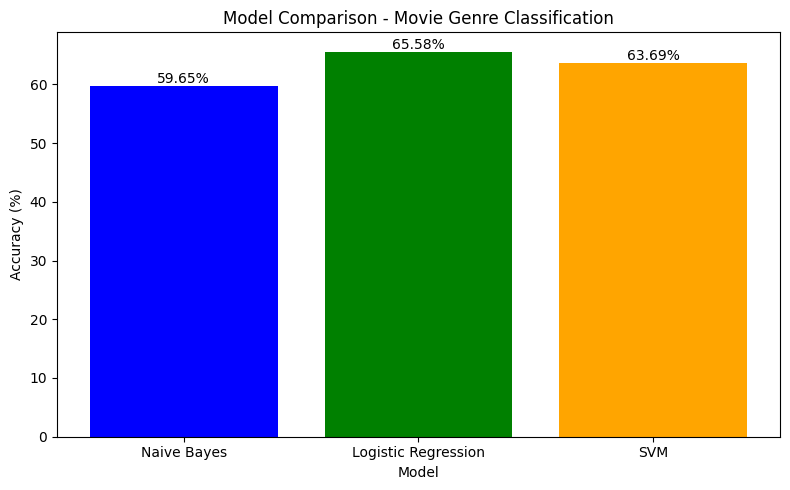

In [14]:
models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracies = [
    accuracy_score(y_test, nb_pred) * 100,
    accuracy_score(y_test, lr_pred) * 100,
    accuracy_score(y_test, svm_pred) * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.title('Model Comparison - Movie Genre Classification')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()